# Disorder

Everything else in matverse assumes a structure is ordered: this atom is here,
that one is there. A large fraction of real materials are not.

A solid solution, a doped semiconductor, a high-entropy alloy and a cathode
part-way through charging all have sites that are **fractionally occupied** —
and a first-principles code cannot take one as input. It needs a specific
arrangement of specific atoms.

Bridging that gap is a bigger problem than it looks. A disordered cell stands
for an *ensemble*, and any single ordered cell you pick is one sample from it.
Which sample you pick changes the answer, and choosing wrongly is one of the
easier ways to compute something confidently meaningless.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 211   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

Three cases spanning the problem: a binary solid solution, a five-component
equiatomic alloy of the kind called *high-entropy*, and an ordered metal for
contrast.

In [2]:
from pymatgen.core import Lattice, Structure


def mixed(occupancies, a=3.7):
    """An fcc cell whose every site is shared between species."""
    return Structure(Lattice.cubic(a), [dict(occupancies)] * 4,
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


md = mv.data.from_structures([
    mixed({"Cu": 0.5, "Au": 0.5}, a=3.8),
    mixed({"Cu": 0.2, "Ni": 0.2, "Co": 0.2, "Fe": 0.2, "Mn": 0.2}),
    mv.structures(mv.datasets.metals(["Cu"]))[0],
])
mv.pp.describe(md)

md.obs[["formula", "nsites", "density"]].round(3)

,formula,nsites,density
0,CuAu,4,15.767
1,Mn0.8Fe0.8Co0.8Cu0.8Ni0.8,4,7.657
2,Cu,4,8.935


Note that `mv.pp.describe` reports a formula for all three — a disordered cell
is a perfectly good structure, it just is not one you can hand to VASP.

## How disordered, and where

In [3]:
mv.disorder.describe(md, temperature=1500.0)

md.obs[["formula", "is_ordered", "n_disordered_sites", "max_site_disorder",
        "configurational_entropy", "entropy_term_300K"]].round(5)

,formula,is_ordered,n_disordered_sites,max_site_disorder,configurational_entropy,entropy_term_300K
0,CuAu,False,4,0.5,0.00006,-0.08960
1,Mn0.8Fe0.8Co0.8Cu0.8Ni0.8,False,4,0.8,0.00014,-0.20804
2,Cu,True,0,0.0,0.00000,-0.00000


`max_site_disorder` is how far the worst site is from having a single owner:
0.5 for an even two-way split, 0.8 for an even five-way split, 0 for an ordered
cell.

## The entropy a zero-temperature hull leaves out

`configurational_entropy` is the ideal mixing entropy per atom. For an
equiatomic mixture of *m* species it has a closed form, `k_B ln m`, which is
worth checking rather than trusting:

In [4]:
predicted = mv.disorder.KB_EV * np.log([2, 5, 1])
pd.DataFrame({
    "formula": md.obs["formula"],
    "computed": md.obs["configurational_entropy"].to_numpy(dtype=float),
    "k_B ln(m)": predicted,
}).round(8)

,formula,computed,k_B ln(m)
0,CuAu,0.000060,0.000060
1,Mn0.8Fe0.8Co0.8Cu0.8Ni0.8,0.000139,0.000139
2,Cu,0.000000,0.000000


Exact. And the consequence is the interesting part.

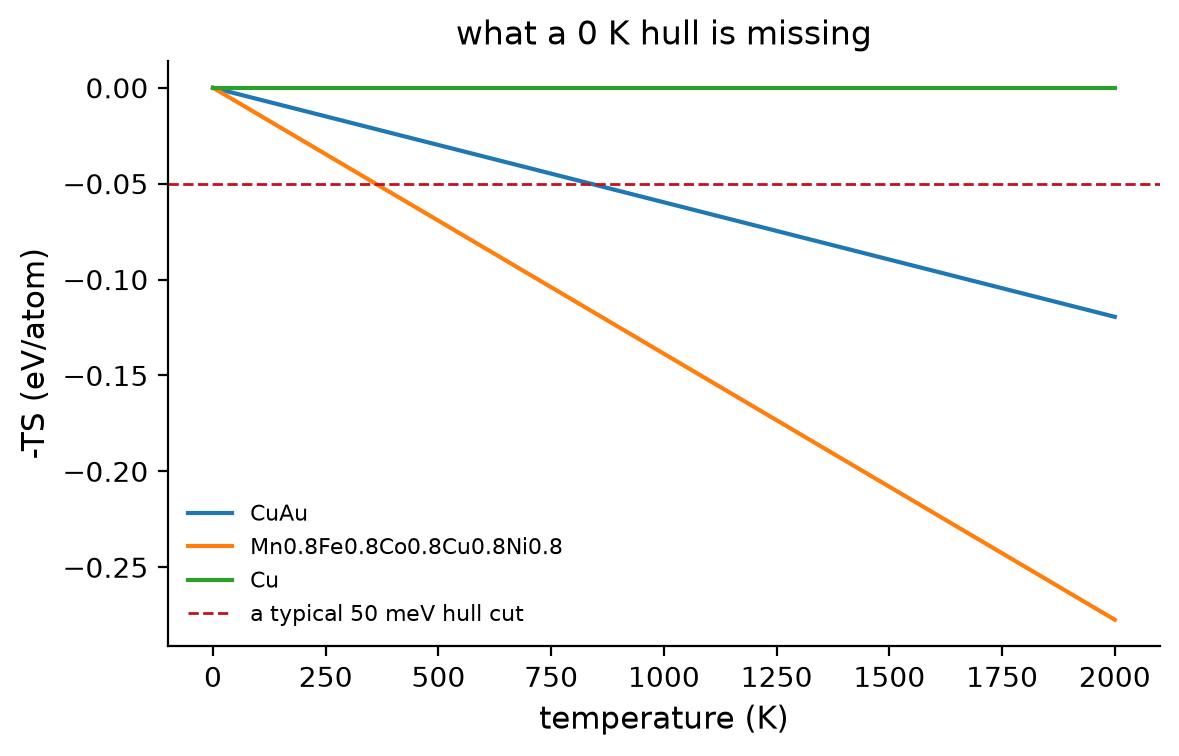

In [5]:
import matplotlib.pyplot as plt

temperatures = np.linspace(0, 2000, 200)
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for formula, entropy in zip(md.obs["formula"],
                            md.obs["configurational_entropy"]):
    ax.plot(temperatures, -temperatures * entropy, label=formula)
ax.axhline(-0.05, linestyle="--", color="#c1121f", linewidth=1.0,
           label="a typical 50 meV hull cut")
ax.set_xlabel("temperature (K)")
ax.set_ylabel("-TS (eV/atom)")
ax.set_title("what a 0 K hull is missing")
ax.legend(fontsize=8)

At room temperature the entropy term is tens of meV and usually ignorable. At a
synthesis temperature of 1500 K the five-component alloy gets **−0.21 eV/atom**
— four times the 50 meV that a screen typically calls "close to the hull".

That is the whole argument for high-entropy alloys: a material can sit well
above the convex hull at 0 K and still be the phase that forms, for no reason
other than that there are a lot of ways to arrange it.

```{warning}
This is an **upper bound**. Real mixing is never ideal, and short-range order —
which is the norm rather than the exception in concentrated alloys — reduces
the entropy below `k_B ln m`. Treating the ideal value as the true one
overstabilises exactly the materials it is used to justify.
```

## Making something a DFT code can read

`mv.disorder.orderings` enumerates specific arrangements and returns them as an
ordinary materials object — the same shape as `mv.mag.orderings` and
`mv.pp.defects`, because it is the same move: enumerate the configurations,
compute them all, let the object record which won.

In [6]:
ordered = mv.disorder.orderings(md, n=3)
mv.pp.describe(ordered)

ordered.obs[["parent", "ordering_index", "formula", "nsites",
             "ewald_energy"]]

,parent,ordering_index,formula,nsites,ewald_energy
0,0,0,CuAu,4,0.0
1,0,1,CuAu,4,0.0
2,0,2,CuAu,4,0.0
3,1,0,MnFeCoNi,4,0.0
4,1,1,MnFeCoNi,4,0.0
5,1,2,MnFeCoNi,4,0.0
6,2,0,Cu,4,NaN


In [7]:
all(s.is_ordered for s in mv.structures(ordered))

True

Every cell is now ordered, and the compositions survived: Cu₀.₅Au₀.₅ became
CuAu, not something else.

The already-ordered copper passed through as a single row rather than being
dropped, so every input material is still represented and nothing needs
re-joining by hand.

### The ranking is arbitrary here, and it says so

In [8]:
ordered.uns["orderings"]

{'source': 'input',
 'n_requested': 3,
 'use_oxidation': False,
 'n_failed': 0,
 'errors': [],
 'note': 'the best n by Ewald energy, not every arrangement; the count of distinct arrangements grows combinatorially',
 'ranking': 'no oxidation states, so every Ewald energy is zero and the order is arbitrary. Honest for an alloy; pass use_oxidation=True for an oxide, where electrostatics is what decides.'}

Arrangements are ranked by **Ewald energy**, which needs oxidation states.
Without them every arrangement scores zero and the order is arbitrary — which
is honest for a metallic alloy, where electrostatics is not what decides
anything, and would be wrong for an oxide. Pass `use_oxidation=True` there.

The object records that rather than presenting an arbitrary order as a result.

```{note}
`n=3` returned three arrangements. There are far more: the count of distinct
arrangements grows combinatorially with cell size, and `uns['orderings']` says
this is a subset. A screen over "the orderings" of a concentrated alloy is
always a screen over a sample.
```

## When ordering is the wrong tool

Here is the trap. `orderings` ranks arrangements and gives you the best ones —
that is, the **ordered ground state**. A solid solution is the opposite of an
ordered ground state.

If you want a cell that behaves like a random alloy, you want a *special
quasirandom structure*: the small cell whose correlation functions best match a
genuinely random one.

In [9]:
try:
    mv.disorder.sqs(md, scaling=1, search_time=0.05)
except ImportError as exc:
    print(f"ImportError: {exc}")

ImportError: mv.disorder.sqs needs ATAT's mcsqs, a separate Fortran program: https://axelvandewalle.github.io/www-avdw/atat/ 

Do not substitute mv.disorder.orderings for it — that gives the ordered ground state, which is the opposite of a solid solution.


It needs ATAT's `mcsqs`, a separate Fortran program, and it refuses rather than
quietly handing back the ordered ground state under a different name. That
substitution would be a plausible-looking answer to a different question, which
is the worst kind of wrong.

## Doping

`mv.disorder.dope` is the dilute case: put a small amount of a dopant onto the
sites its charge and ionic radius allow, and compensate the charge. That is
different from `mv.gen.substitute`, which swaps *every* atom of an element.

In [10]:
oxide = mv.datasets.load("oxides")[:1].copy()
mv.pp.describe(oxide)
oxide.obs[["name", "formula", "nsites"]]

,name,formula,nsites
0,SrTiO3,SrTiO3,5


In [11]:
try:
    doped = mv.disorder.dope(oxide, "Nb5+", min_length=5.0)
    print(doped.obs[["parent", "dopant", "formula"]])
except ValueError as exc:
    print(f"ValueError: {exc}")

ValueError: no doped structure was produced for 'Nb5+'. pymatgen's DopingTransformation enumerates with **enumlib**, a separate Fortran program, and returns an empty list rather than raising when it is missing — so this is usually a missing install rather than a chemistry answer. Get it from https://github.com/msg-byu/enumlib.

If enumlib is present, the dopant may genuinely fit nowhere: check its charge and ionic radius against the host sites.


That message is the point of the function existing at all.

pymatgen's `DopingTransformation` enumerates internally with **enumlib**, a
separate Fortran program. When enumlib is missing it does not raise — it
returns an **empty list**, so a doping study runs to completion and produces
nothing, and the only symptom is a dataset with fewer rows than you expected.

matverse checks for the empty result and tells you which of the two things
happened: a missing install, or a dopant that genuinely fits nowhere.

## Where this sits

Disorder touches the rest of the library in one specific place: the hull.

```python
mv.disorder.describe(md, temperature=1500.0)
mv.thermo.hull(md, level='pbe')

# a candidate is really "on the hull at temperature" if
md.obs['e_above_hull_pbe'] + md.obs['entropy_term_300K'] <= 0
```

A screen that ignores `-TS` will reject exactly the high-entropy phases that
motivated the field.

## What it remembers

In [12]:
for step in mv.provenance(ordered):
    print(step)

data.from_structures
disorder.orderings(source='input', n=3, use_oxidation=False)
pp.describe(source='input')


```{seealso}
[Magnetic ordering](magnetic_ordering.ipynb) is the same enumerate-then-compute
shape applied to spin. [Screening, end to end](screening.ipynb) is the hull this
entropy term belongs in.
```

## What can this be alloyed with?

Before enumerating an ordered approximant there is a prior question: which of
your materials can be alloyed with which at all? Two materials form a
pseudobinary system when one species swaps for another on the same structure and
the rest of the lattice stays put.

`mv.gen.alloy_pairs` enumerates them. The III–V semiconductors are the case
where every answer is known in advance:

In [13]:
from pymatgen.core import Lattice, Structure

def zincblende(a, cation, anion="As"):
    return Structure.from_spacegroup(
        "F-43m", Lattice.cubic(a), [cation, anion],
        [[0, 0, 0], [0.25, 0.25, 0.25]])

iii_v = mv.data.from_structures([
    zincblende(5.653, "Ga"), zincblende(5.661, "Al"),
    zincblende(6.058, "In"),
    Structure.from_spacegroup("Fd-3m", Lattice.cubic(5.431), ["Si"],
                              [[0, 0, 0]])])
iii_v.obs["name"] = ["GaAs", "AlAs", "InAs", "Si"]

pairs = mv.gen.alloy_pairs(iii_v)
pairs.obs[["name", "pair_formula", "substituting", "observer",
           "lattice_mismatch"]].round(4)

,name,pair_formula,substituting,observer,lattice_mismatch
0,AlAs-GaAs,AlAs_GaAs,Al-Ga,As,0.0014
1,GaAs-InAs,GaAs_InAs,Ga-In,As,0.0692
2,AlAs-InAs,AlAs_InAs,Al-In,As,0.0678


Three pairs out of four materials, and the missing one is the point. **Silicon
is refused against all three arsenides**, even though it shares their lattice
type and sits between them in size:

In [14]:
pairs.uns["alloy_pairs"]["refused"]

['GaAs/Si: InvalidAlloy: Alloys are not commensurate',
 'AlAs/Si: InvalidAlloy: Alloys are not commensurate',
 'InAs/Si: InvalidAlloy: Alloys are not commensurate']

"Not commensurate" — there is no species you can swap to get from Si to GaAs
while leaving a sublattice in place. That is a chemical criterion, not a
geometric one, and it is the reason to ask this question with a function rather
than by comparing lattice constants.

The mismatches are the textbook ones. **AlAs–GaAs at 0.14%** is the canonical
lattice-matched pair, which is why AlGaAs heterostructures grow essentially
defect-free and ended up inside every laser diode and every high-electron-
mobility transistor. **GaAs–InAs at 7%** is the canonical mismatched one.

```{warning}
Do not read `lattice_mismatch` as a miscibility criterion. InGaAs is a real
material with real devices built on it — the 7% is why it is grown strained and
thin, deliberately. Filter on this column when you care about epitaxy, not when
you care about whether the alloy exists.
```

`substituting` and `observer` say which sublattice the disorder lives on: the
cations swap, the arsenic stays. That is exactly what the SQS below has to
enumerate over, and it is worth knowing before you start.

## Did the disorder work?

Everything above produces a cell that is *supposed* to stand for a solid
solution. Nothing so far checks whether it does. The measure for that is the
Warren–Cowley short-range order parameter, one per ordered pair of elements:

$$\alpha_{AB} = 1 - \frac{P(B \mid A)}{c_B}$$

where $P(B\mid A)$ is the chance that a neighbour of an A atom is a B atom and
$c_B$ is B's overall fraction. **Zero is random.** Negative means A prefers B —
ordering. Positive means A avoids B, so A clusters with its own kind.

The structure that fixes the signs in your head is B2 brass, where every nearest
neighbour of a copper is a zinc:

In [15]:
from pymatgen.core import Lattice, Structure

b2 = Structure(Lattice.cubic(2.95), ["Cu", "Zn"], [[0, 0, 0], [.5, .5, .5]])

# the same lattice, same composition, atoms thrown on at random
base = b2.copy()
base.make_supercell([4, 4, 4])
pick = np.random.RandomState(0).permutation(len(base))
solution = Structure(
    base.lattice,
    ["Cu" if pick[i] < len(base) // 2 else "Zn" for i in range(len(base))],
    base.frac_coords)

alloys = mv.data.from_structures([b2, solution])
alloys.obs_names = ["B2 CuZn", "random CuZn"]

mv.disorder.sro(alloys)
pd.DataFrame(alloys.obsm["sro_shell1"], index=alloys.obs_names,
             columns=alloys.uns["sro"]["shell1"]["pairs"]).round(3)

,Cu-Cu,Cu-Zn,Zn-Cu,Zn-Zn
B2 CuZn,1.000,-1.000,-1.000,1.000
random CuZn,0.031,-0.031,-0.031,0.031


**+1 for the like pairs and −1 for the unlike ones** on B2, which is what
perfect ordering means, and 0.03 across the board for the random arrangement —
zero to within the noise of a 128-site cell.

Two properties worth knowing are visible in that table. The matrix is symmetric
here because the two concentrations are equal, and each row satisfies
$\sum_B c_B \alpha_{AB} = 0$: the neighbours of a copper are *some* element,
whatever the ordering. That sum rule is the one identity that catches a
normalisation mistake, and it is checked in the test suite rather than left to
the eye.

The shell matters, and it is the second argument:

In [16]:
for k in (1, 2, 3):
    mv.disorder.sro(alloys, shell=k, key_added=f"shell{k}")

pd.DataFrame(
    {f"shell {k}": alloys.obsm[f"sro_shell{k}"][0] for k in (1, 2, 3)},
    index=alloys.uns["sro"]["shell1"]["pairs"]).round(3)

,shell 1,shell 2,shell 3
Cu-Cu,1.0,-1.0,-1.0
Cu-Zn,-1.0,1.0,1.0
Zn-Cu,-1.0,1.0,1.0
Zn-Zn,1.0,-1.0,-1.0


The sign **inverts** between the first shell and the second. In bcc the eight
nearest neighbours sit along $\langle 111\rangle$ and in B2 they are the other
species; the six second neighbours sit along $\langle 100\rangle$ and are the
same species. So $\alpha_{\mathrm{CuCu}}$ goes from $+1$ to $-1$. A short-range
order parameter quoted without its shell is half a number.

```{note}
Computed from the definition rather than through pymatgen's
`analysis.disorder`, whose `get_warren_cowley_parameters` returns the same value
for every pair — on this B2 cell it gives −1 for the like pairs as well as the
unlike ones. A wrapper around output that cannot be reproduced from the
definition is worse than the gap.
```

`obs['sro_rms_shell1']` is the single number to sort on: near zero for a good
solid solution, large for anything that has ordered or clustered.

## An effective Hamiltonian, and what it buys

Everything above reads order off a structure you already have. The question a
screen actually asks is the other way round: *at what temperature does this
alloy order at all?* That is a collective effect — no single ordered cell shows
it — and answering it means visiting millions of configurations.

A **cluster expansion** makes that affordable. Fit the energy to correlation
functions of the lattice once, and afterwards scoring a configuration costs a
dot product instead of a calculator call.

`mv.disorder.cluster_expansion` fits it. The model lands on the disordered
**parent**, because the parent is what owns the sublattice; the training object
gets predictions and residuals so the fit can be inspected row by row.

In [17]:
import numpy as np
from pymatgen.core import Lattice, Structure

a = 3.9
prim = Structure(Lattice([[0, a/2, a/2], [a/2, 0, a/2], [a/2, a/2, 0]]),
                 [{"Cu": 0.5, "Au": 0.5}], [[0, 0, 0]])
parent = mv.data.from_structures([prim])
parent.obs_names = ["CuAu"]

# Random decorations of the fcc lattice, over several supercell shapes.
rng, cells = np.random.default_rng(0), []
for _ in range(60):
    shape = [(2, 2, 2), (1, 2, 3), (1, 1, 4), (2, 2, 3)][rng.integers(4)]
    base = prim.copy()
    base.make_supercell(list(shape))
    n_cu = int(rng.integers(0, len(base) + 1))
    species = ["Cu"] * n_cu + ["Au"] * (len(base) - n_cu)
    rng.shuffle(species)
    cells.append(Structure(base.lattice, species, base.frac_coords))

training = mv.data.from_structures(cells)
mv.calc.energy(training, level="emt")

try:
    mv.disorder.cluster_expansion(training, parent=parent, level="emt",
                                  cutoffs={2: 6.0, 3: 4.5})
    fit = parent.uns["cluster_expansion"]["emt"]
    print(f"{fit['n_structures']} structures, {fit['n_features']} clusters, "
          f"rank {fit['rank']}")
    print(f"training {fit['train_rmse']*1000:.3f} meV/prim, "
          f"CV {fit['cv_rmse']*1000:.3f} meV/prim")
except ImportError:
    print("needs smol; pip install matverse[alloys]")

60 structures, 8 clusters, rank 8
training 0.504 meV/prim, CV 0.564 meV/prim


The number that says whether a cluster expansion is any good is the
**cross-validated** error, never the training error — adding clusters drives
training error to zero whether or not they mean anything.

The other number to read is the **rank**. Sixty structures for eight clusters
looks comfortable and can still be under-determined: on a training set of one
supercell shape the rank came out 6, so two clusters had coefficients the data
never determined and least-squares quietly picked the smallest ones. Varying the
supercell *shape* is what fixes that — more structures of the same shape do not.
`mv.disorder.cluster_expansion` warns when the rank falls short.

Now the part the expansion was for:

In [18]:
try:
    mv.disorder.monte_carlo(
        parent, level="emt", supercell=(4, 4, 4), steps=120000,
        temperatures=(200., 260., 320., 380., 440., 560., 700.))

    T = mv.grid_of(parent, "mc_energy")
    C = parent.obsm["mc_heat_capacity_emt"][0]
    for t, c in zip(T, C):
        print(f"{t:6.0f} K   C = {c*1e5:7.2f} x 1e-5 eV/K/site")
    print("\ntransition:",
          parent.obs["order_disorder_temperature_emt"].iloc[0], "K")
except (ImportError, KeyError):
    print("needs smol; pip install matverse[alloys]")

   200 K   C =    0.00 x 1e-5 eV/K/site
   260 K   C =    3.72 x 1e-5 eV/K/site
   320 K   C =   12.19 x 1e-5 eV/K/site
   380 K   C =    3.94 x 1e-5 eV/K/site
   440 K   C =    1.92 x 1e-5 eV/K/site
   560 K   C =    1.33 x 1e-5 eV/K/site
   700 K   C =    0.99 x 1e-5 eV/K/site

transition: 320.0 K


A heat capacity that is flat everywhere except one sharp peak, and the peak is
the order-disorder transition.

Two guards are worth knowing about, because both were put in after the
straightforward version returned a confident wrong answer:

```{warning}
**A maximum is not a peak.** At a 3×3×3 cell this same system gives a heat
capacity flat to within 20%, and its maximum sits wherever the noise was
largest — it moved from 380 K to 260 K on nothing but longer chains. A maximum
below `min_prominence=` times the median is reported as **NaN**, not as a
temperature. The fix is a larger `supercell=`: a transition is collective, and a
cell too small to hold the ordered domain cannot show one however long you
sample it.

**A peak on the edge is not resolved either.** An edge maximum means either the
transition is outside the range or the coldest chains never equilibrated, and a
chain still relaxing has a large energy variance that looks exactly like a
fluctuation. Also NaN, with the reason in
`uns['monte_carlo'][level]['unresolved_transitions']`.
```

One cross-check costs nothing. The heat capacity comes from the energy
*variance*; $d\langle E\rangle/dT$ across the sweep is an independent route to
the same quantity. Where the sampling is good the two agree to a couple of
percent, and where they disagree the sampling is not good — which is a more
useful statement than any single number.

```{note}
`threads=` defaults to 1 deliberately. smol defaults it to the CPU count, and
for these cell sizes that is a catastrophic default rather than a fast one: one
swap is a few dozen multiply-adds and spawning a thread team per evaluation
costs far more. Measured on a 17-core node, 2000 steps on 27 sites took 62 s at
the default and 0.10 s at one thread — a factor of 620.
```